
# Lab 9: Quantun Computing - Rabi Oscillations
Sofía Moscoso Ortiz

In [5]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile

## Exercise 1: $NH_3$ molecule

An example of the quantum oscillations in two-level systems may be rather unexpected; for example, the ammonium molecule

![NH3](../Sesiones/QC/figures/NH3.png)
![NH3](NH3.png)

 It has two symmetric states that differ by the inversion of the nitrogen atom relative to the plane of the three hydrogen atoms, which are weakly coupled due to quantum-mechanical tunneling of the nitrogen atom through the plane of the hydrogen atoms. Since for this particular molecule, in the absence of external fields, the level splitting $\Delta E$ corresponds to an experimentally convenient frequency $\Omega/2\pi\approx$ 24.79 GHz.

 1. Supose a detuning frequency $\Omega_R/2$.
 2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is $\ket{2}$.

 [see](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Essential_Graduate_Physics_-_Quantum_Mechanics_(Likharev)/05%3A_Some_Exactly_Solvable_Problems/5.01%3A_Two-level_Systems)

Omega = 155760163764.98193
Delta = 77880081882.49097
Omega_eff = 174145157182.4996
Rabi frequency = 27716062581.109894 Hz


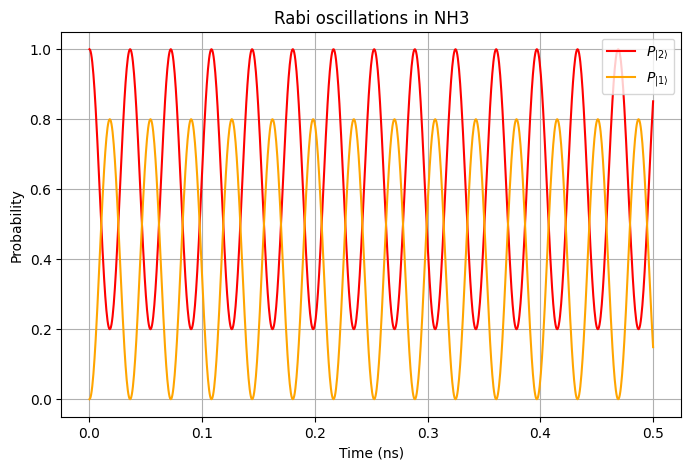

In [13]:
# Transition frequency
f0 = 24.79e9          # Hz
Omega = 2*np.pi*f0    # rad/s


delta = Omega/2 # Detuning
Omega_eff = np.sqrt(Omega**2 + delta**2) # Effective Rabi frequency

print("Omega =", Omega)
print("Delta =", delta)
print("Omega_eff =", Omega_eff)
print("Rabi frequency =", Omega_eff/(2*np.pi), "Hz")

t = np.linspace(0,5e-10,1000)

P2 = 1-(Omega/Omega_eff)**2*np.sin(Omega_eff*t/2)**2
P1 = 1-P2

plt.figure(figsize=(8,5))
plt.plot(t*1e9,P2, color = "red" , label=r'$P_{|2\rangle}$')
plt.plot(t*1e9,P1,color = "orange" ,label=r'$P_{|1\rangle}$')
plt.xlabel("Time (ns)")
plt.ylabel("Probability")
plt.title("Rabi oscillations in NH3")
plt.grid(True)
plt.legend()
plt.show()

## Exercise: Bell state

1. Creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a `Bell state`  (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.


In [7]:
qc = QuantumCircuit(2,2)

qc.h(0)
qc.cx(0,1)

qc.measure([0,1],[0,1])

print(qc.draw())

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


In [8]:
sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print(counts)

{'11': 490, '00': 534}


Los estados 00 y 11 aparecen con aproximadamente la misma probabilidad, podemos decir entonces que los dos qubits están entrelazados


2. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.


In [9]:
qc = QuantumCircuit(3,3)

qc.h(0)
qc.cx(0,1)
qc.cx(1,2)

qc.measure([0,1,2],[0,1,2])

print(qc.draw())

     ┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 


In [10]:
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print(counts)

{'111': 543, '000': 481}


Con tres qubits tambien observamos que quedan entrelazados, formando un estado tipo GHZ


3. See your results shift by adding qc.x(1) to the end of the circuit.

In [12]:
qc = QuantumCircuit(3,3)

qc.h(0)
qc.cx(0,1)
qc.cx(1,2)
qc.x(1)

qc.measure([0,1,2],[0,1,2])
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print(counts)

{'101': 545, '010': 479}


La compuerta X invierte el segundo qubit (0↔1), desplazando los resultados desde 000 y 111 hacia 010 y 101 pero manteniendo el entrelazamiento del sistema

Nota: 5.0... muy bien por acercarse a estos temas. 